# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import csv
import pandas as pd
from parso.python.tree import String

In [2]:
# credit: https://www.kaggle.com/willkoehrsen/start-here-a-gentle-introduction

def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.\n A total of " + str(mis_val.sum() / df.size) + " values are missing.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [3]:
from sklearn.model_selection import train_test_split

train = pd.read_csv("C:\\Users\\jcani\\ML Data\\train_data.csv", nrows=100000)
train_labels = pd.read_csv("C:\\Users\\jcani\\ML Data\\train_labels.csv", nrows=100000)
missing_values_table(train)
    


Your selected dataframe has 190 columns.
There are 117 columns that have missing values.
 A total of 0.15281868421052633 values are missing.


,Missing Values,% of Total Values
D_87,99927,99.9
D_88,99850,99.8
D_108,99470,99.5
D_110,99366,99.4
D_111,99366,99.4
...,...,...
S_26,21,0.0
B_41,21,0.0
R_20,5,0.0
S_23,5,0.0


In [4]:
missing_values = missing_values_table(train)
features_missing_values = missing_values.index.tolist()

Your selected dataframe has 190 columns.
There are 117 columns that have missing values.
 A total of 0.15281868421052633 values are missing.


Ultimate goal: find if there is a correlation between missing values and the dependent variable
First check how many customers have at least 1 not missing value.
Next check if there are customers that have more than 1 variables that are not missing and how many.
This can have multiple categories, 0 filled in, 1 filled in ... 13 filled in. Make a nice plot
Then dependent on the problem choose the right correlation test. If all customers have only 1 filled in
then calculate the correlation between two binary variables.

In [5]:
class Customer:
    customer_id = ""
    missing_value_count = {}
    existing_value_count = {}
    
    def __init__(self, customer_id):
        self.customer_id = customer_id
        self.missing_value_count = {}
        self.existing_value_count = {}
        
    def get_target_value(self, labels):
        target = labels.loc[labels['customer_ID'] == self.customer_id]['target']
        target_value = 0
        if target is not None:
            target_value = target.iloc[0]
        return target_value
    
    def get_ratio_existing_to_all(self, feature):
        if feature not in self.existing_value_count.keys():
            return 0
        
        if feature not in self.missing_value_count.keys():
            return 1
        ratio =  self.existing_value_count[feature] / (self.existing_value_count[feature] + self.missing_value_count[feature])
        return ratio
    
def find_customer(customers, customer_id):
    for customer in customers:
        if customer.customer_id == customer_id:
            return customer
    return None
            
def add_existing_or_missing_count(customer, idx, feature):
    if math.isnan(train[feature][idx]):
        if feature in customer.missing_value_count.keys():
            customer.missing_value_count[feature] += 1
        else:
            customer.missing_value_count[feature] = 1
    else:
        if feature in customer.existing_value_count.keys():
            customer.existing_value_count[feature] += 1
        else:
            customer.existing_value_count[feature] = 1

In [24]:
import math
import csv
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

delinquency_features = ['D_138', 'D_106','D_132','D_49','D_66','D_76','D_42', 'D_142','D_53','D_82','D_50','D_105', 'D_56', 'D_77', 'D_43'] 
customers = []
for feature in delinquency_features:  #[20:30]:#features_missing_values: #['D_132','D_108','D_82', 'D_50']:#[9:12]:
    for idx in range(len(train)):
        customer_found = find_customer(customers, train['customer_ID'][idx])
        if customer_found is None:
            customer_found = Customer(train['customer_ID'][idx])
        
        #if train[feature][idx] is String:
        #    print("string: " + train[feature][idx])
        #    continue 
            
        add_existing_or_missing_count(customer_found, idx, feature)
        if customer_found not in customers:
            customers.append(customer_found)
   

ratios = pd.DataFrame()     
for feature in delinquency_features:#features_missing_values[20:30]:
    ratio = [customer.get_ratio_existing_to_all(feature) for customer in customers]
    ratios[feature] = ratio


default_values = [customer.get_target_value(train_labels) for customer in customers]
X = sm.add_constant(ratios)  # Independent variable
Y = pd.DataFrame({'target':default_values})
x_train, x_test, y_train, y_test = train_test_split(X, Y)


One possible option is for the missing variables to just use the ratio instead. To test this a model could be trained on only the existing value ratio and see how it performs. This should then be compared to the baseline. If the results are promosing we could even use it in the final model.

In [50]:
model = sm.Logit(Y_train, X_train).fit(method='bfgs')

# Summary of the model

y_pred_probs = model.predict(X_test)
threshold = 0.5
y_pred = (y_pred_probs >= threshold).astype(int)
# Calculate accuracy
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)
print(model.summary())

         Current function value: 0.396773
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36
Accuracy: 0.7764423076923077
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 1248
Model:                          Logit   Df Residuals:                     1237
Method:                           MLE   Df Model:                           10
Date:                Wed, 15 Jan 2025   Pseudo R-squ.:                  0.2977
Time:                        14:59:47   Log-Likelihood:                -495.17
converged:                      False   LL-Null:                       -705.07
Covariance Type:            nonrobust   LLR p-value:                 5.732e-84
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9085      0.247    -11.790    

C:\Users\jcani\miniconda3\Lib\site-packages\scipy\optimize\_optimize.py:1291: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
C:\Users\jcani\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:

def get_balanced_data(X, Y): 
    default_count = 0
    for y in Y['target']:
        default_count += y
    
    indices = []
    X_balanced = pd.DataFrame(columns=X.columns)
    Y_balanced = pd.DataFrame(columns=Y.columns)
    count_not_default = 0
    for idx in range(len(Y['target'])):
        if Y['target'].iloc[idx] == 0 and count_not_default < default_count:
            count_not_default += 1
            indices.append(idx)
            
        if Y['target'].iloc[idx] == 1:
            indices.append(idx)
    
    
    Y_balanced = Y.iloc[indices]
    X_balanced = X.iloc[indices]
    return X_balanced, Y_balanced

x_train, y_train = get_balanced_data(x_train, y_train)


In [30]:
def print_ratio(Y):
    default_count = 0
    for y in Y['target']:
        default_count += y
    
    print(default_count/len(Y['target']))
    
print_ratio(y_train)
print_ratio(y_test)

0.5
0.2806171648987464


In [39]:
from sklearn.metrics import confusion_matrix
model = sm.Logit(y_train, x_train).fit(method='bfgs')

# Summary of the model

y_pred_probs = model.predict(x_test)
threshold = 0.5
y_pred = (y_pred_probs >= threshold).astype(int)
print(len(y_pred))
print( len([y for y in y_pred if y==1]))


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix)


         Current function value: 0.509284
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
2074
804
Accuracy: 0.7569913211186113
[[1129  363]
 [ 141  441]]


C:\Users\jcani\miniconda3\Lib\site-packages\scipy\optimize\_optimize.py:1291: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
C:\Users\jcani\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [112]:
import statsmodels.formula.api as smf

model_linear_regression = sm.OLS(y_train, x_train).fit()
y_pred_probs = model_linear_regression.predict(x_test)
threshold = 0.5
y_pred = (y_pred_probs >= threshold).astype(int)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(model_linear_regression.summary())

Accuracy: 0.7463837994214079
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     104.6
Date:                Wed, 15 Jan 2025   Prob (F-statistic):          5.44e-265
Time:                        20:15:21   Log-Likelihood:                -1760.4
No. Observations:                3314   AIC:                             3553.
Df Residuals:                    3298   BIC:                             3650.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3326  

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X_balanced, Y_balanced)

model = sm.Logit(y_train, x_train).fit(method='bfgs')

# Summary of the model

y_pred_probs = model.predict(x_test)
threshold = 0.5
y_pred = (y_pred_probs >= threshold).astype(int)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
#print(model.summary())

NameError: name 'X_balanced' is not defined

In [27]:
def amex_metric(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:

    def top_four_percent_captured(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
        df = (pd.concat([y_true, y_pred], axis='columns')
              .sort_values('prediction', ascending=False))
        df['weight'] = df['target'].apply(lambda x: 20 if x==0 else 1)
        four_pct_cutoff = int(0.04 * df['weight'].sum())
        df['weight_cumsum'] = df['weight'].cumsum()
        df_cutoff = df.loc[df['weight_cumsum'] <= four_pct_cutoff]
        return (df_cutoff['target'] == 1).sum() / (df['target'] == 1).sum()
        
    def weighted_gini(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
        df = (pd.concat([y_true, y_pred], axis='columns')
              .sort_values('prediction', ascending=False))
        df['weight'] = df['target'].apply(lambda x: 20 if x==0 else 1)
        df['random'] = (df['weight'] / df['weight'].sum()).cumsum()
        total_pos = (df['target'] * df['weight']).sum()
        df['cum_pos_found'] = (df['target'] * df['weight']).cumsum()
        df['lorentz'] = df['cum_pos_found'] / total_pos
        df['gini'] = (df['lorentz'] - df['random']) * df['weight']
        return df['gini'].sum()

    def normalized_weighted_gini(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
        y_true_pred = y_true.rename(columns={'target': 'prediction'})
        return weighted_gini(y_true, y_pred) / weighted_gini(y_true, y_true_pred)

    g = normalized_weighted_gini(y_true, y_pred)
    d = top_four_percent_captured(y_true, y_pred)

    return 0.5 * (g + d)

In [33]:


target_df = pd.DataFrame(y_test, index=y_test.index)
pred_df = pd.DataFrame(data={ "prediction": y_pred }, index=y_test.index)

print(amex_metric(target_df, pred_df))

0.3191662651789955


In [ ]:


model = sm.Logit(Y_balanced, X_balanced).fit(method='bfgs')

# Summary of the model

y_pred_probs = model.predict(x_test)
threshold = 0.5
y_pred = (y_pred_probs >= threshold).astype(int)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
#print(model.summary())

In [27]:
import matplotlib.pyplot as plt

categories = []
correlation_existing = []
correlation_missing = []
with open("correlation.csv", 'r', newline='') as csvfile:
    csvreader = csv.DictReader(csvfile)
    print(csvreader['category'])
    for row in csvreader:
        #print(row)
        categories.append(row['category'])
        correlation_existing.append(row['correlation_existing'])
        correlation_missing.append(row['correlation_missing'])

plt.bar(categories[:5], correlation_existing[:5])
plt.ylim(0,0.5)    


TypeError: 'DictReader' object is not subscriptable

[26, 23, 15, 21, 16]


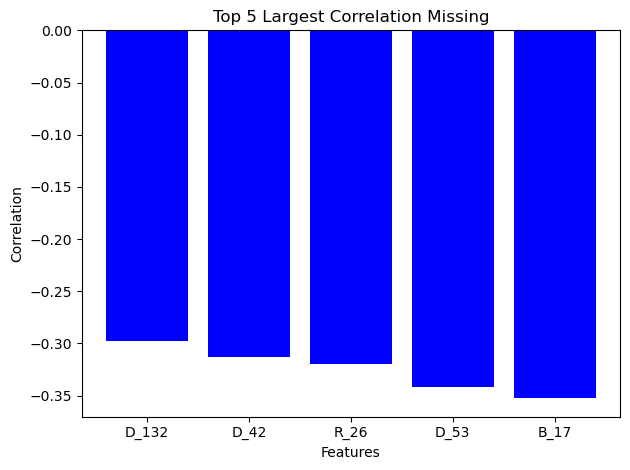

In [85]:
import pandas as pd
df = pd.read_csv('correlation.csv')

abs_col1 = df['correlation_missing'].abs()
abs_col2 = df['correlation_existing'].abs()

n_top = 5
# Get the top 5 absolute max indexes for each column
top_missing_idx = abs_col1.nlargest(n_top).index.tolist()
top_existing_idx = abs_col2.nlargest(n_top).index.tolist()
print(top_missing_idx)

#fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

top_missing_categories = []
top_missing_correlation = []
for idx in list(reversed(top_missing_idx)):
    top_missing_categories.append(df.loc[idx, 'category'])
    top_missing_correlation.append(df.loc[idx, 'correlation_missing'])
    
top_existing_categories = []
top_existing_correlation = []
for idx in top_existing_idx:
    top_existing_categories.append(df.loc[idx, 'category'])
    top_existing_correlation.append(df.loc[idx, 'correlation_existing'])
# Bar graph for col1
plt.bar(top_missing_categories, top_missing_correlation, color='blue')
plt.title('Top '+ str(n_top) +  ' Largest Correlation Missing')
plt.xlabel('Features')
plt.ylabel('Correlation')

# Bar graph for col2
#axes[1].bar(top_existing_categories, top_existing_correlation, color='green')
#axes[1].set_title('Top ' + str(n_top) + ' Largest Correlation Existing')
#axes[1].set_xlabel('Row Index')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [39]:
import math
import statistics as st
def print_value_range(data, column):
    values = []
    for value in data.loc[:, column]:
        if math.isnan(value) == False:
            values.append(value)
    
    print("mean: ", st.mean(values))
    print("min", min(values))
    print("max", max(values))
    print("median", st.median(values))
    
    
print_value_range(train, "D_108")

mean:  0.10015302054752512
min 1.126898795717035e-05
max 2.007924500074186
median 0.0053223045124944
